In [1]:
import numpy as np
import matplotlib.pyplot as plt


def load_ensemble_results(filepath_or_array):
    """
    Load ensemble output file or accept a pre-loaded array.
    
    Returns dict with named columns:
        geo, gender, year, age, mu, total_var, aleatoric_var, epistemic_var, lower_95, upper_95
    """
    if isinstance(filepath_or_array, np.ndarray):
        data = filepath_or_array
    else:
        data = np.genfromtxt(filepath_or_array)
    return {
        'geo': data[:, 0],
        'gender': data[:, 1],
        'year': data[:, 2],
        'age': data[:, 3],
        'mu': data[:, 4],
        'total_var': data[:, 5],
        'aleatoric_var': data[:, 6],
        'epistemic_var': data[:, 7],
        'lower_95': data[:, 8],
        'upper_95': data[:, 9],
    }


def inner_join_on_keys(actual_data, ens):
    """
    Inner join actual_data and ensemble results on (geo, gender, year, age).
    
    Args:
        actual_data: array with columns [geo, gender, year, age, rate]
        ens: dict from load_ensemble_results
    
    Returns:
        actual_data_matched: subset of actual_data rows that match ensemble keys
        ens_matched: dict with same keys as ens, subset to matching rows
    """
    # Build keys as tuples for both datasets
    actual_keys = {
        (actual_data[i, 0], actual_data[i, 1], actual_data[i, 2], actual_data[i, 3]): i
        for i in range(len(actual_data))
    }
    
    ens_n = len(ens['geo'])
    actual_idx = []
    ens_idx = []
    for j in range(ens_n):
        key = (ens['geo'][j], ens['gender'][j], ens['year'][j], ens['age'][j])
        if key in actual_keys:
            actual_idx.append(actual_keys[key])
            ens_idx.append(j)
    
    actual_idx = np.array(actual_idx)
    ens_idx = np.array(ens_idx)
    
    actual_matched = actual_data[actual_idx]
    ens_matched = {k: v[ens_idx] for k, v in ens.items()}
    
    return actual_matched, ens_matched


def compute_metrics(actual, predicted, variance, lower, upper):
    """
    Compute accuracy and calibration metrics for a set of predictions.
    
    Returns dict of metrics:
        - rmse: root mean squared error
        - mae: mean absolute error
        - mean_var: average predicted variance (higher = less certain)
        - mean_aleatoric: average aleatoric variance (not computed here, passed separately)
        - coverage_95: fraction of actuals falling within 95% interval
        - avg_interval_width: average width of 95% interval
        - nll: average Gaussian negative log-likelihood
        - n: number of observations
    """
    residuals = actual - predicted
    rmse = np.sqrt(np.mean(residuals**2))
    mae = np.mean(np.abs(residuals))
    
    # Coverage: what fraction of actuals fall inside the 95% interval?
    inside = (actual >= lower) & (actual <= upper)
    coverage_95 = np.mean(inside)
    
    # Average interval width
    avg_width = np.mean(upper - lower)
    
    # Average predicted variance
    mean_var = np.mean(variance)
    
    # Gaussian NLL (same formula as training loss)
    nll = np.mean(0.5 * np.log(variance) + 0.5 * residuals**2 / variance)
    
    n = len(actual)
    
    return {
        'rmse': rmse,
        'mae': mae,
        'nll': nll,
        'mean_var': mean_var,
        'coverage_95': coverage_95,
        'avg_interval_width': avg_width,
        'n': n,
    }


def print_metrics(metrics, label=""):
    """Print a metrics dict in a readable format."""
    if label:
        print(f"\n{'='*60}")
        print(f"  {label}")
        print(f"{'='*60}")
    print(f"  N observations:        {metrics['n']}")
    print(f"  RMSE:                  {metrics['rmse']:.6f}")
    print(f"  MAE:                   {metrics['mae']:.6f}")
    print(f"  NLL:                   {metrics['nll']:.4f}")
    print(f"  Mean variance:         {metrics['mean_var']:.6f}")
    print(f"  95% coverage:          {metrics['coverage_95']:.3f}  (target: 0.950)")
    print(f"  Avg interval width:    {metrics['avg_interval_width']:.4f}")


def evaluate_ensemble(actual_data, ensemble_filepath, lograte=True):
    """
    Full evaluation of ensemble predictions against actuals.
    
    Args:
        actual_data: raw data array with columns [geo, gender, year, age, rate]
        ensemble_filepath: path to ensemble output file, or pre-loaded array
        lograte: if True, predictions are in log space. Actuals will be log-transformed 
                 to match before computing metrics.
    """
    ens = load_ensemble_results(ensemble_filepath)
    
    # Inner join on (geo, gender, year, age) so rows are aligned
    actual_data, ens = inner_join_on_keys(actual_data, ens)
    print(f"  Matched {len(actual_data)} rows after inner join on (geo, gender, year, age)")
    
    actual_rates = actual_data[:, 4]
    if lograte:
        epsilon = 9e-06
        actual = np.log(np.maximum(actual_rates, epsilon))
    else:
        actual = actual_rates

    # ================================================================
    # OVERALL METRICS
    # ================================================================
    overall = compute_metrics(actual, ens['mu'], ens['total_var'], ens['lower_95'], ens['upper_95'])
    print_metrics(overall, "OVERALL")
    
    # Also report average aleatoric vs epistemic split
    print(f"\n  Uncertainty decomposition:")
    print(f"    Avg aleatoric var:   {np.mean(ens['aleatoric_var']):.6f}  "
          f"({np.mean(ens['aleatoric_var']) / np.mean(ens['total_var']) * 100:.1f}% of total)")
    print(f"    Avg epistemic var:   {np.mean(ens['epistemic_var']):.6f}  "
          f"({np.mean(ens['epistemic_var']) / np.mean(ens['total_var']) * 100:.1f}% of total)")

    # ================================================================
    # BY GENDER
    # ================================================================
    print(f"\n{'='*60}")
    print(f"  BY GENDER")
    print(f"{'='*60}")
    for g_val, g_label in [(0, 'Female'), (1, 'Male')]:
        mask = ens['gender'] == g_val
        if np.sum(mask) == 0:
            continue
        m = compute_metrics(actual[mask], ens['mu'][mask], ens['total_var'][mask],
                           ens['lower_95'][mask], ens['upper_95'][mask])
        print(f"\n  --- {g_label} ---")
        print(f"  N: {m['n']}  |  RMSE: {m['rmse']:.6f}  |  MAE: {m['mae']:.6f}  |  "
              f"NLL: {m['nll']:.4f}  |  Coverage: {m['coverage_95']:.3f}  |  "
              f"Width: {m['avg_interval_width']:.4f}")

    # ================================================================
    # BY AGE GROUP
    # ================================================================
    print(f"\n{'='*60}")
    print(f"  BY AGE GROUP")
    print(f"{'='*60}")
    age_bins = [(0, 1), (1, 5), (5, 15), (15, 25), (25, 45), (45, 65), (65, 85), (85, 100)]
    age_labels = ['0', '1-4', '5-14', '15-24', '25-44', '45-64', '65-84', '85+']
    
    age_results = []
    for (lo, hi), label in zip(age_bins, age_labels):
        if lo == 85:
            mask = ens['age'] >= lo
        else:
            mask = (ens['age'] >= lo) & (ens['age'] < hi)
        if np.sum(mask) == 0:
            continue
        m = compute_metrics(actual[mask], ens['mu'][mask], ens['total_var'][mask],
                           ens['lower_95'][mask], ens['upper_95'][mask])
        m['label'] = label
        m['avg_epistemic'] = np.mean(ens['epistemic_var'][mask])
        m['avg_aleatoric'] = np.mean(ens['aleatoric_var'][mask])
        age_results.append(m)
        print(f"  Age {label:>5s}  |  N: {m['n']:>7d}  |  RMSE: {m['rmse']:.6f}  |  "
              f"Coverage: {m['coverage_95']:.3f}  |  Epistemic: {m['avg_epistemic']:.6f}  |  "
              f"Aleatoric: {m['avg_aleatoric']:.6f}")

    # ================================================================
    # BY COUNTRY (top 20 by observation count)
    # ================================================================
    print(f"\n{'='*60}")
    print(f"  BY COUNTRY (top 20 by N)")
    print(f"{'='*60}")
    unique_geos = np.unique(ens['geo'])
    
    country_results = []
    for geo in unique_geos:
        mask = ens['geo'] == geo
        m = compute_metrics(actual[mask], ens['mu'][mask], ens['total_var'][mask],
                           ens['lower_95'][mask], ens['upper_95'][mask])
        m['geo'] = int(geo)
        m['avg_epistemic'] = np.mean(ens['epistemic_var'][mask])
        m['avg_aleatoric'] = np.mean(ens['aleatoric_var'][mask])
        country_results.append(m)
    
    # Sort by N descending, show top 20
    country_results.sort(key=lambda x: x['n'], reverse=True)
    print(f"  {'Geo':>5s}  |  {'N':>7s}  |  {'RMSE':>8s}  |  {'Coverage':>8s}  |  "
          f"{'NLL':>8s}  |  {'Epistemic':>10s}  |  {'Aleatoric':>10s}")
    print(f"  {'-'*5}  |  {'-'*7}  |  {'-'*8}  |  {'-'*8}  |  "
          f"{'-'*8}  |  {'-'*10}  |  {'-'*10}")
    for m in country_results[:20]:
        print(f"  {m['geo']:>5d}  |  {m['n']:>7d}  |  {m['rmse']:>8.6f}  |  {m['coverage_95']:>8.3f}  |  "
              f"{m['nll']:>8.4f}  |  {m['avg_epistemic']:>10.6f}  |  {m['avg_aleatoric']:>10.6f}")

    return overall, age_results, country_results


# ============================================================================
# PLOTTING
# ============================================================================

def plot_coverage_by_age(age_results):
    """Bar chart of 95% coverage by age group with target line."""
    labels = [r['label'] for r in age_results]
    coverages = [r['coverage_95'] for r in age_results]
    
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(labels, coverages, color='steelblue', alpha=0.8)
    ax.axhline(y=0.95, color='red', linestyle='--', linewidth=1.5, label='Target (95%)')
    ax.set_ylabel('Coverage')
    ax.set_xlabel('Age Group')
    ax.set_title('95% Prediction Interval Coverage by Age Group')
    ax.set_ylim(0.8, 1.0)
    ax.legend()
    
    # Add value labels on bars
    for bar, cov in zip(bars, coverages):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{cov:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    return fig


def plot_uncertainty_decomposition_by_age(age_results):
    """Stacked bar chart showing aleatoric vs epistemic uncertainty by age."""
    labels = [r['label'] for r in age_results]
    aleatoric = [r['avg_aleatoric'] for r in age_results]
    epistemic = [r['avg_epistemic'] for r in age_results]
    
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(labels))
    ax.bar(x, aleatoric, label='Aleatoric (data noise)', color='steelblue', alpha=0.8)
    ax.bar(x, epistemic, bottom=aleatoric, label='Epistemic (model disagreement)', color='coral', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel('Average Variance')
    ax.set_xlabel('Age Group')
    ax.set_title('Uncertainty Decomposition by Age Group')
    ax.legend()
    
    plt.tight_layout()
    return fig


def plot_predictions_vs_actual(actual_data, ensemble_filepath, lograte=True, sample_size=2000):
    """Scatter plot of predicted vs actual with uncertainty bands."""
    ens = load_ensemble_results(ensemble_filepath)
    
    # Inner join so rows match
    actual_data, ens = inner_join_on_keys(actual_data, ens)
    
    actual_rates = actual_data[:, 4]
    if lograte:
        epsilon = 9e-06
        actual = np.log(np.maximum(actual_rates, epsilon))
    else:
        actual = actual_rates
    
    # Subsample for readability
    if len(actual) > sample_size:
        idx = np.random.choice(len(actual), sample_size, replace=False)
    else:
        idx = np.arange(len(actual))
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Left: predicted vs actual
    ax = axes[0]
    ax.scatter(actual[idx], ens['mu'][idx], alpha=0.3, s=5, color='steelblue')
    lims = [min(actual[idx].min(), ens['mu'][idx].min()),
            max(actual[idx].max(), ens['mu'][idx].max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual (log rate)' if lograte else 'Actual (rate)')
    ax.set_ylabel('Predicted (log rate)' if lograte else 'Predicted (rate)')
    ax.set_title('Predicted vs Actual')
    ax.legend()
    
    # Right: residuals vs predicted uncertainty
    ax = axes[1]
    residuals = np.abs(actual[idx] - ens['mu'][idx])
    uncertainty = np.sqrt(ens['total_var'][idx])
    ax.scatter(uncertainty, residuals, alpha=0.3, s=5, color='steelblue')
    # Add diagonal: if well-calibrated, |residual| ~ std on average
    lims = [0, max(uncertainty.max(), residuals.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='|residual| = std')
    ax.set_xlabel('Predicted Std Dev')
    ax.set_ylabel('|Residual|')
    ax.set_title('Absolute Error vs Predicted Uncertainty')
    ax.legend()
    
    plt.tight_layout()
    return fig



    
    fig2 = plot_uncertainty_decomposition_by_age(age_test)
    fig2.savefig('../data/ensemble_uncertainty_decomposition.png', dpi=150)
    
    fig3 = plot_predictions_vs_actual(country_test, '../data/dl_country_freeze_ensemble_forecast.txt', lograte=True)
    fig3.savefig('../data/ensemble_pred_vs_actual.png', dpi=150)
    
    print("\nPlots saved.")
    plt.show()


############################################################
  TEST SET EVALUATION
############################################################
  Matched 79400 rows after inner join on (geo, gender, year, age)

  OVERALL
  N observations:        79400
  RMSE:                  0.405550
  MAE:                   0.199954
  NLL:                   -0.8877
  Mean variance:         0.167804
  95% coverage:          0.983  (target: 0.950)
  Avg interval width:    1.4054

  Uncertainty decomposition:
    Avg aleatoric var:   0.164662  (98.1% of total)
    Avg epistemic var:   0.003143  (1.9% of total)

  BY GENDER

  --- Female ---
  N: 39700  |  RMSE: 0.419514  |  MAE: 0.209958  |  NLL: -0.8550  |  Coverage: 0.982  |  Width: 1.5034

  --- Male ---
  N: 39700  |  RMSE: 0.391089  |  MAE: 0.189951  |  NLL: -0.9203  |  Coverage: 0.983  |  Width: 1.3074

  BY AGE GROUP
  Age     0  |  N:     794  |  RMSE: 0.325314  |  Coverage: 0.951  |  Epistemic: 0.006631  |  Aleatoric: 0.115807
  Age   1-4  |  

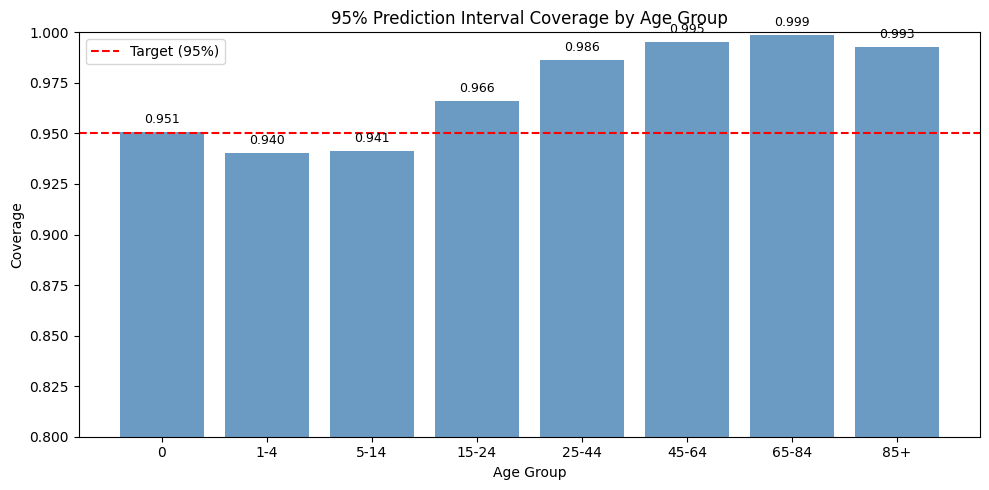

In [6]:
# ============================================================================
# MAIN: run evaluation for freeze ensemble
# ============================================================================

if __name__ == "__main__":
    # Load raw data for ground truth rates
    country_test = np.loadtxt('../../data/country_test_orig.txt')
    country_training = np.loadtxt('../../data/country_training_orig.txt')

    # Evaluate test set
    print("\n" + "#"*60)
    print("  TEST SET EVALUATION")
    print("#"*60)
    overall_test, age_test, country_test_results = evaluate_ensemble(
        country_test, '../../data/dl_country_freeze_ensemble_forecast.txt', lograte=True
    )

    # Evaluate training set
    print("\n\n" + "#"*60)
    print("  TRAINING SET EVALUATION")
    print("#"*60)
    overall_train, age_train, country_train_results = evaluate_ensemble(
        country_training, '../../data/dl_country_freeze_ensemble_fitted.txt', lograte=True
    )

    # Generate plots for test set
    fig1 = plot_coverage_by_age(age_test)
    fig1.savefig('../../data/freeze_ensemble_coverage_by_age.png', dpi=150)

(80000, 10)
(352000, 10)

############################################################
  TEST SET EVALUATION
############################################################
  Matched 79400 rows after inner join on (geo, gender, year, age)

  OVERALL
  N observations:        79400
  RMSE:                  0.020553
  MAE:                   0.005131
  NLL:                   -6.5607
  Mean variance:         871.545888
  95% coverage:          0.894  (target: 0.950)
  Avg interval width:    2.7547

  Uncertainty decomposition:
    Avg aleatoric var:   nan  (nan% of total)
    Avg epistemic var:   nan  (nan% of total)

  BY GENDER

  --- Female ---
  N: 39700  |  RMSE: 0.014258  |  MAE: 0.004139  |  NLL: -6.8657  |  Coverage: 0.909  |  Width: 0.0755

  --- Male ---
  N: 39700  |  RMSE: 0.025329  |  MAE: 0.006123  |  NLL: -6.2557  |  Coverage: 0.879  |  Width: 5.4340

  BY AGE GROUP
  Age     0  |  N:     794  |  RMSE: 0.000993  |  Coverage: 0.869  |  Epistemic: nan  |  Aleatoric: nan
  Age   1-

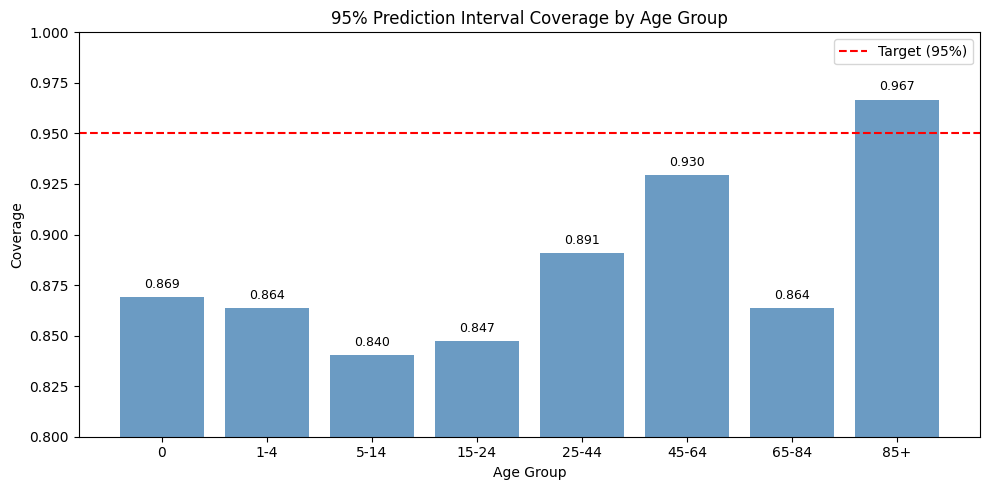

In [7]:
# ============================================================================
# MAIN: run evaluation for coherent
# ============================================================================

if __name__ == "__main__":
    # Load raw data for ground truth rates
    country_test = np.loadtxt('../../data/country_test_orig.txt')
    country_training = np.loadtxt('../../data/country_training_orig.txt')
    coherent_forecast = np.genfromtxt('../../data/coherent_forecast.txt')
    coherent_fitted = np.genfromtxt('../../data/coherent_fitted.txt')
    print(coherent_forecast.shape)
    print(coherent_fitted.shape)

    # Evaluate test set
    print("\n" + "#"*60)
    print("  TEST SET EVALUATION")
    print("#"*60)
    overall_test, age_test, country_test_results = evaluate_ensemble(
        country_test, coherent_forecast, lograte=False
    )

    # Evaluate training set
    print("\n\n" + "#"*60)
    print("  TRAINING SET EVALUATION")
    print("#"*60)
    overall_train, age_train, country_train_results = evaluate_ensemble(
        country_training, coherent_fitted, lograte=False
    )

    # Generate plots for test set
    fig1 = plot_coverage_by_age(age_test)
    fig1.savefig('../../data/ensemble_coverage_by_age.png', dpi=150)

In [ ]:
# ============================================================================
# Winkler Interval Score for both models
# ============================================================================
# The Winkler score penalizes wide intervals and adds a penalty when the
# actual value falls outside the interval.  For a (1-α) PI [l, u]:
#   - y in [l,u]:  score = (u - l)
#   - y < l:       score = (u - l) + (2/α)(l - y)
#   - y > u:       score = (u - l) + (2/α)(y - u)
# Lower is better.  α = 0.05 for a 95% interval.

alpha = 0.05
epsilon = 9e-06

# --- Align actuals (log space) ---
actual_logrates_all = np.log(np.maximum(country_test[:, 4], epsilon))

# --- Helper ---
def winkler_score(actual, lower, upper, alpha=0.05):
    """Compute the Winkler interval score for each observation."""
    width = upper - lower
    penalty = np.where(
        actual < lower,
        (2 / alpha) * (lower - actual),
        np.where(actual > upper, (2 / alpha) * (actual - upper), 0.0),
    )
    return width + penalty

# --- Freeze ensemble (DL) ---
freeze_actual_matched, freeze_ens_matched = inner_join_on_keys(country_test, freeze_ens)
freeze_actual_log = np.log(np.maximum(freeze_actual_matched[:, 4], epsilon))
freeze_winkler = winkler_score(
    freeze_actual_log,
    freeze_ens_matched['lower_95'],
    freeze_ens_matched['upper_95'],
    alpha,
)

# --- Coherent ---
coherent_actual_matched, coherent_ens_matched = inner_join_on_keys(country_test, coherent_ens)
coherent_actual_log = np.log(np.maximum(coherent_actual_matched[:, 4], epsilon))
coherent_winkler = winkler_score(
    coherent_actual_log,
    coherent_ens_matched['lower_95'],
    coherent_ens_matched['upper_95'],
    alpha,
)

# --- Print results ---
print(f"{'Model':<20s}  {'Mean Winkler':>14s}  {'Median Winkler':>14s}")
print(f"{'-'*20}  {'-'*14}  {'-'*14}")
print(f"{'DL Ensemble':<20s}  {np.mean(freeze_winkler):>14.4f}  {np.median(freeze_winkler):>14.4f}")
print(f"{'Coherent':<20s}  {np.mean(coherent_winkler):>14.4f}  {np.median(coherent_winkler):>14.4f}")


Model                   Mean Winkler  Median Winkler
--------------------  --------------  --------------
DL Ensemble                   1.7134          1.1231
Coherent                      1.6054          0.6996


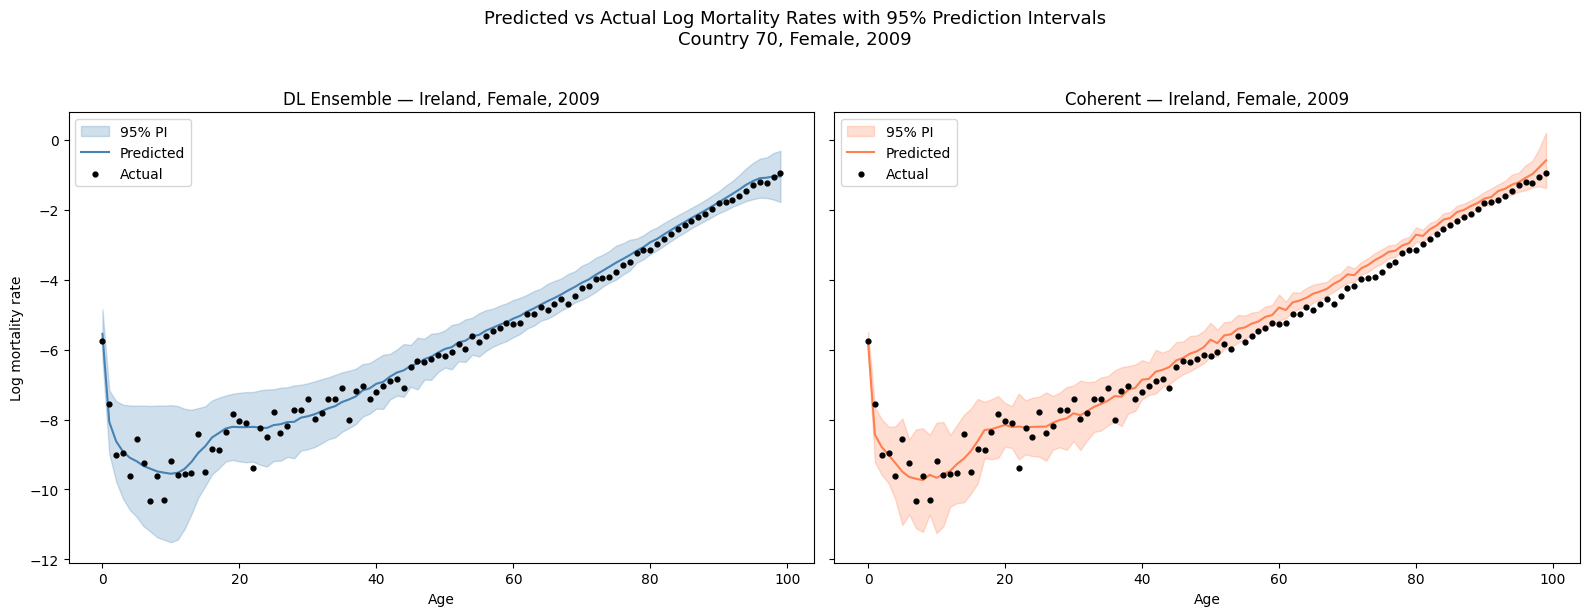

In [ ]:
# ============================================================================
# Plot actual vs predicted log rates with 95% PIs for a single slice
# ============================================================================

# --- Choose a year, gender, and country ---
YEAR = 2009
GENDER = 0       # 0 = Female, 1 = Male
GEO = 70           # country code (numeric index from data)

gender_label = 'Male' if GENDER == 1 else 'Female'
epsilon = 9e-06

# --- Filter freeze ensemble ---
freeze_mask = (
    (freeze_ens['year'] == YEAR) &
    (freeze_ens['gender'] == GENDER) &
    (freeze_ens['geo'] == GEO)
)

# --- Filter coherent ---
coherent_mask = (
    (coherent_ens['year'] == YEAR) &
    (coherent_ens['gender'] == GENDER) &
    (coherent_ens['geo'] == GEO)
)

# --- Filter actuals ---
actual_mask = (
    (country_test[:, 2] == YEAR) &
    (country_test[:, 1] == GENDER) &
    (country_test[:, 0] == GEO)
)
actual_ages = country_test[actual_mask, 3]
actual_logrates = np.log(np.maximum(country_test[actual_mask, 4], epsilon))

# Sort by age for clean line plots
freeze_order = np.argsort(freeze_ens['age'][freeze_mask])
coherent_order = np.argsort(coherent_ens['age'][coherent_mask])
actual_order = np.argsort(actual_ages)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# --- Left panel: Freeze Ensemble (DL) ---
ax = axes[0]
ages_f = freeze_ens['age'][freeze_mask][freeze_order]
mu_f = freeze_ens['mu'][freeze_mask][freeze_order]
lo_f = freeze_ens['lower_95'][freeze_mask][freeze_order]
hi_f = freeze_ens['upper_95'][freeze_mask][freeze_order]

ax.fill_between(ages_f, lo_f, hi_f, alpha=0.25, color='steelblue', label='95% PI')
ax.plot(ages_f, mu_f, color='steelblue', linewidth=1.5, label='Predicted')
ax.scatter(actual_ages[actual_order], actual_logrates[actual_order],
           color='black', s=12, zorder=5, label='Actual')
ax.set_xlabel('Age')
ax.set_ylabel('Log mortality rate')
ax.set_title(f'DL Ensemble — Ireland, {gender_label}, {YEAR}')
ax.legend()

# --- Right panel: Coherent ---
ax = axes[1]
ages_c = coherent_ens['age'][coherent_mask][coherent_order]
mu_c = coherent_ens['mu'][coherent_mask][coherent_order]
lo_c = coherent_ens['lower_95'][coherent_mask][coherent_order]
hi_c = coherent_ens['upper_95'][coherent_mask][coherent_order]

ax.fill_between(ages_c, lo_c, hi_c, alpha=0.25, color='coral', label='95% PI')
ax.plot(ages_c, mu_c, color='coral', linewidth=1.5, label='Predicted')
ax.scatter(actual_ages[actual_order], actual_logrates[actual_order],
           color='black', s=12, zorder=5, label='Actual')
ax.set_xlabel('Age')
ax.set_title(f'Coherent — Ireland, {gender_label}, {YEAR}')
ax.legend()

plt.suptitle(f'Predicted vs Actual Log Mortality Rates with 95% Prediction Intervals\n'
             f'Country {GEO}, {gender_label}, {YEAR}', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../../data/ireland_example.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
np.load('../../data/geos_key.npy')

array([['AK', '0'],
       ['AL', '1'],
       ['AZ', '2'],
       ['AR', '3'],
       ['CA', '4'],
       ['CO', '5'],
       ['CT', '6'],
       ['DE', '7'],
       ['FL', '8'],
       ['GA', '9'],
       ['HI', '10'],
       ['ID', '11'],
       ['IL', '12'],
       ['IN', '13'],
       ['IA', '14'],
       ['KS', '15'],
       ['KY', '16'],
       ['LA', '17'],
       ['ME', '18'],
       ['MD', '19'],
       ['MA', '20'],
       ['MI', '21'],
       ['MN', '22'],
       ['MS', '23'],
       ['MO', '24'],
       ['MT', '25'],
       ['NE', '26'],
       ['NV', '27'],
       ['NH', '28'],
       ['NJ', '29'],
       ['NM', '30'],
       ['NY', '31'],
       ['NC', '32'],
       ['ND', '33'],
       ['OH', '34'],
       ['OK', '35'],
       ['OR', '36'],
       ['PA', '37'],
       ['RI', '38'],
       ['SC', '39'],
       ['SD', '40'],
       ['TN', '41'],
       ['TX', '42'],
       ['UT', '43'],
       ['VT', '44'],
       ['VA', '45'],
       ['WA', '46'],
       ['WV', '47'],
  

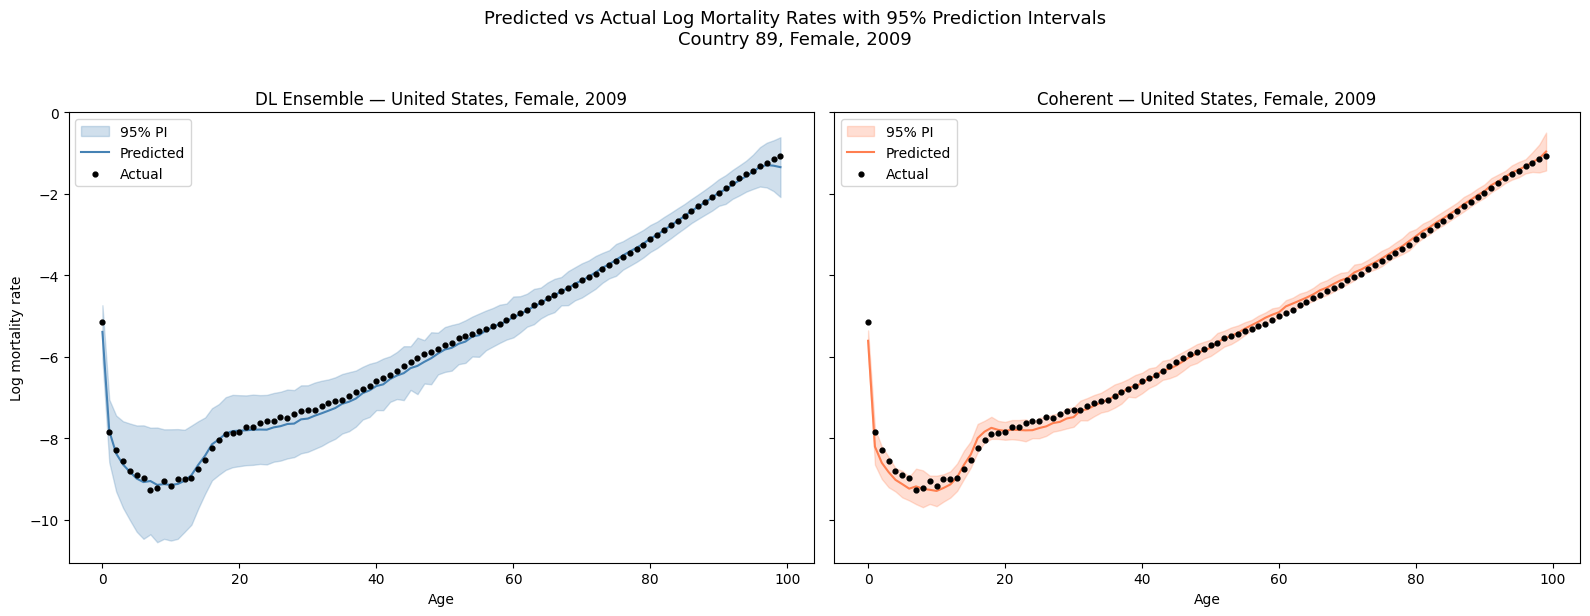

In [ ]:
# ============================================================================
# Plot actual vs predicted log rates with 95% PIs for a single slice
# ============================================================================

# --- Choose a year, gender, and country ---
YEAR = 2009
GENDER = 0       # 0 = Female, 1 = Male
GEO = 89           # country code (numeric index from data)

gender_label = 'Male' if GENDER == 1 else 'Female'
epsilon = 9e-06

# --- Filter freeze ensemble ---
freeze_mask = (
    (freeze_ens['year'] == YEAR) &
    (freeze_ens['gender'] == GENDER) &
    (freeze_ens['geo'] == GEO)
)

# --- Filter coherent ---
coherent_mask = (
    (coherent_ens['year'] == YEAR) &
    (coherent_ens['gender'] == GENDER) &
    (coherent_ens['geo'] == GEO)
)

# --- Filter actuals ---
actual_mask = (
    (country_test[:, 2] == YEAR) &
    (country_test[:, 1] == GENDER) &
    (country_test[:, 0] == GEO)
)
actual_ages = country_test[actual_mask, 3]
actual_logrates = np.log(np.maximum(country_test[actual_mask, 4], epsilon))

# Sort by age for clean line plots
freeze_order = np.argsort(freeze_ens['age'][freeze_mask])
coherent_order = np.argsort(coherent_ens['age'][coherent_mask])
actual_order = np.argsort(actual_ages)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# --- Left panel: Freeze Ensemble (DL) ---
ax = axes[0]
ages_f = freeze_ens['age'][freeze_mask][freeze_order]
mu_f = freeze_ens['mu'][freeze_mask][freeze_order]
lo_f = freeze_ens['lower_95'][freeze_mask][freeze_order]
hi_f = freeze_ens['upper_95'][freeze_mask][freeze_order]

ax.fill_between(ages_f, lo_f, hi_f, alpha=0.25, color='steelblue', label='95% PI')
ax.plot(ages_f, mu_f, color='steelblue', linewidth=1.5, label='Predicted')
ax.scatter(actual_ages[actual_order], actual_logrates[actual_order],
           color='black', s=12, zorder=5, label='Actual')
ax.set_xlabel('Age')
ax.set_ylabel('Log mortality rate')
ax.set_title(f'DL Ensemble — United States, {gender_label}, {YEAR}')
ax.legend()

# --- Right panel: Coherent ---
ax = axes[1]
ages_c = coherent_ens['age'][coherent_mask][coherent_order]
mu_c = coherent_ens['mu'][coherent_mask][coherent_order]
lo_c = coherent_ens['lower_95'][coherent_mask][coherent_order]
hi_c = coherent_ens['upper_95'][coherent_mask][coherent_order]

ax.fill_between(ages_c, lo_c, hi_c, alpha=0.25, color='coral', label='95% PI')
ax.plot(ages_c, mu_c, color='coral', linewidth=1.5, label='Predicted')
ax.scatter(actual_ages[actual_order], actual_logrates[actual_order],
           color='black', s=12, zorder=5, label='Actual')
ax.set_xlabel('Age')
ax.set_title(f'Coherent — United States, {gender_label}, {YEAR}')
ax.legend()

plt.suptitle(f'Predicted vs Actual Log Mortality Rates with 95% Prediction Intervals\n'
             f'Country {GEO}, {gender_label}, {YEAR}', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../../data/usa_example.png', dpi=150, bbox_inches='tight')
plt.show()